# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [2]:
import pandas as pd
import numpy as np

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet("tracks.parquet")
catalog_names = pd.read_parquet("catalog_names.parquet")
events = pd.read_parquet("interactions.parquet")

In [4]:
display(tracks.head(3))
display(catalog_names.head(3))
display(events.head(3))

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [5]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [6]:
catalog_names.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   id      1812471 non-null  int64 
 1   type    1812471 non-null  object
 2   name    1812471 non-null  object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [7]:
events.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Non-Null Count      Dtype         
---  ------      --------------      -----         
 0   user_id     222629898 non-null  int32         
 1   track_id    222629898 non-null  int32         
 2   track_seq   222629898 non-null  int16         
 3   started_at  222629898 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


Пропусков нет

В catalog_names track_id хранится в int64, а в interactions int32.

In [8]:
catalog_names['id'].max()

101521819

Максимальный id умещается в int32

In [9]:
catalog_names['id'] = catalog_names['id'].astype("int32")
tracks['track_id'] = tracks['track_id'].astype('int32')

Проверим есть ли треки с неизвестными исполнителями, альбомами или жанрами.

In [10]:
tracks_ = tracks.explode(column=['artists'])
na_count = tracks_['artists'].isna().sum()
print(na_count, na_count / tracks.shape[0])

15369 0.015369


У 1,5 % треков неизвестен испольнитель

In [11]:
catalog_artist_ids = set(catalog_names.query("type == 'artist'")['id'])


track_artist_ids = {artist_id for sublist in tracks['artists'].dropna() for artist_id in sublist}

missing_artists = track_artist_ids - catalog_artist_ids
print("Количество несуществующих артистов:", len(missing_artists))

Количество несуществующих артистов: 0


In [12]:
tracks_id = set(tracks['track_id'].unique())
catalog_tracks = set(catalog_names.query('type == "track"')['id'].unique())
missing_tracks = tracks_id - catalog_tracks
missing_tracks

set()

In [13]:
print((tracks['genres'].apply(len) == 0).sum())

genres_id = [ids for subsample in tracks['genres'] for ids in subsample]
missing_genres = set(genres_id) - set(catalog_names.query("type == 'genre'")['id'].unique())
print(len(missing_genres))

3687
30


Есть треки жанр которых не указан или нет каталоге

In [14]:
print((tracks['albums'].apply(len) == 0).sum())

genres_id = [ids for subsample in tracks['albums'] for ids in subsample]
missing_genres = set(genres_id) - set(catalog_names.query("type == 'album'")['id'].unique())
print(len(missing_genres))

18
0


In [15]:
print("Несуществующие треки:", set(events['track_id'].unique()) 
      - set(catalog_names.query('type == "track"')['id'].unique()))

Несуществующие треки: set()


In [16]:
events['started_at'].describe()

count                        222629898
mean     2022-08-29 16:39:44.541336320
min                2022-01-01 00:00:00
25%                2022-07-02 00:00:00
50%                2022-09-15 00:00:00
75%                2022-11-09 00:00:00
max                2022-12-31 00:00:00
Name: started_at, dtype: object

С датами видимых проблем не наблюдается

In [17]:
# 1. Заменяем пустые списки на [-1] 
for col in ['artists', 'albums', 'genres']:
    tracks[col] = tracks[col].apply(lambda x: [-1] if (len(x) == 0) else x)

# 2. Находим 30 жанров, которых нет в справочнике catalog_names
track_genres = {g_id for sublist in tracks['genres'].dropna() for g_id in sublist
    if g_id != -1
}
catalog_genres = set(catalog_names.query("type == 'genre'")['id'])
missing_genre_ids = track_genres - catalog_genres

# 3. Добавляем недостающие жанры и заглушку -1 в catalog_names
unknown_records = [{'id': -1, 'type': 'genre', 'name': 'Unknown'}] + [
    {'id': g_id, 'type': 'genre', 'name': 'Unknown'}
    for g_id in missing_genre_ids
]

catalog_names = pd.concat([catalog_names, pd.DataFrame(unknown_records)], ignore_index=True)

# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

1) Явные пропуски: на уровне колонок таблиц явные пропуски (NaN/None) отсутствуют во всех трёх датасетах.
2) Несоответствие типов и потребление памяти: в датасете взаимодействий events (interactions.parquet) идентификаторы user_id и track_id сохранены как int32, при этом таблица насчитывает более 222,6 млн строк и занимает 5.4 GB оперативной памяти. В таблицах catalog_names и tracks идентификаторы изначально были представлены типом int64
3) У 15 369 треков (~1.54%) не указаны исполнители (пустые списки [] в поле artists). При этом все указанные в датасете артисты присутствуют в справочнике catalog_names
4) У 18 треков не указан альбом (пустые списки [] в поле albums), все существующие идентификаторы альбомов валидны относительно справочника имён.
5) У 3 687 треков не указан жанр (пустые списки [] в поле genres). Кроме того, обнаружено 30 идентификаторов жанров, которые присутствуют в треках, но полностью отсутствуют в справочнике

1) Идентификаторы в справочнике catalog_names (и tracks) приведены к int32, а не расширены до int64, это можно сделать, потому что максимальный идентификатор в каталоге существенно меньше верхней границы диапазона типа int32.

2) Обработка треков с неизвестными метаданными:
  Пустые списки `[]` в колонках `artists`, `albums` и `genres` заменены на значение `[-1]`, обозначающее категорию `Unknown`[cite: 3]. Это позволяет сохранить треки в каталоге, не искажая пользовательские взаимодействия в `events`[cite: 3].
3) Устранение пропусков в справочнике жанров: 
  В `catalog_names` добавлены записи с наименованием `'Unknown'` для технической заглушки `-1` и 30 идентификаторов жанров, отсутствовавших в справочнике.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [18]:
tracks_per_user = events.groupby(['user_id'])['track_id'].count()
with pd.option_context('display.float_format', '{:.2f}'.format):
  display(tracks_per_user.describe())

count   1373221.00
mean        162.12
std         351.28
min           1.00
25%          23.00
50%          55.00
75%         154.00
max       16637.00
Name: track_id, dtype: float64

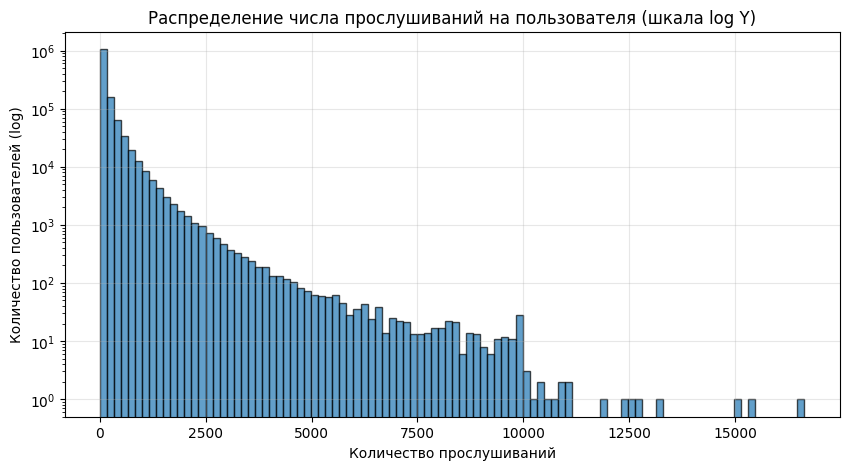

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
tracks_per_user.hist(bins=100, log=True, edgecolor='black', alpha=0.7)
plt.title('Распределение числа прослушиваний на пользователя (шкала log Y)')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (log)')
plt.grid(alpha=0.3)

Наиболее популярные треки

In [20]:
popularity = events.groupby(['track_id']).agg(count = ("track_id", "count")).sort_values(by='count', ascending=False)
popularity = popularity.merge(catalog_names.query("type == 'track'"), how='left', left_on='track_id', right_on='id')
print(popularity.head(10))

    count        id   type                     name
0  111062     53404  track  Smells Like Teen Spirit
1  106921  33311009  track                 Believer
2  101924    178529  track                     Numb
3   99490  35505245  track               I Got Love
4   86670  65851540  track                   Юность
5   86246  24692821  track           Way Down We Go
6   85886  32947997  track             Shape of You
7   85244  51241318  track               In The End
8   85042    795836  track        Shape Of My Heart
9   84748  45499814  track                     Life


Наиболее популярные жанры

In [21]:
track_counts = events['track_id'].value_counts()
tracks_genres = tracks[['track_id', 'genres']].explode('genres')
tracks_genres['plays'] = tracks_genres['track_id'].map(track_counts).fillna(0)
genre_counts = (tracks_genres.groupby('genres')['plays'].sum().reset_index(name='count'))
genres = (
    genre_counts.merge(
        catalog_names.query("type == 'genre'")[['id', 'name']],
        left_on='genres',
        right_on='id',
        how='left',
    )
    .sort_values(by='count', ascending=False)[['name', 'count']]
    .reset_index(drop=True)
)

genres.head(10)

,name,count
0,pop,55578312
1,rap,37799821
2,allrock,31092013
3,ruspop,26626241
4,rusrap,25303695
5,electronics,20120981
6,dance,16291557
7,rusrock,13166147
8,rock,12772644
9,metal,12437375


Треки, которые никто не прослушал

In [22]:
tracks_0 = set(tracks['track_id'].unique()) - set(events['track_id'].unique())
print("Количество непрослушанных треков:", len(tracks_0))
print(f"Доля от каталога: {len(tracks_0) / len(tracks):.2%}")

Количество непрослушанных треков: 0
Доля от каталога: 0.00%


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

Оставиим только пользователей у которых больше  2 прослушанных трека.

In [23]:
user_counts = events['user_id'].value_counts()
valid_users = user_counts[user_counts > 2].index
events = events[events['user_id'].isin(valid_users)]

In [24]:
events = events.rename(columns={'track_id': 'item_id'})
tracks = tracks.rename(columns={'track_id': 'item_id'})

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [25]:
tracks.to_parquet("items.parquet")
events.to_parquet("events.parquet")

In [26]:
import os
from dotenv import load_dotenv

load_dotenv()

AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
ENDPOINT_URL = os.getenv("S3_ENDPOINT_URL")  
BUCKET_NAME = os.getenv("S3_BUCKET_NAME") 

storage_options = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {"endpoint_url": ENDPOINT_URL},
}

items_s3_path = f"s3://{BUCKET_NAME}/recsys/data/items.parquet"
events_s3_path = f"s3://{BUCKET_NAME}/recsys/data/events.parquet"

tracks.to_parquet(items_s3_path, storage_options=storage_options, index=False)
events.to_parquet(events_s3_path, storage_options=storage_options, index=False)

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [ ]:
import gc

variables_to_delete = [
    'events',
    'tracks',
    'catalog_names',
    'tracks_',
    'tracks_genres',
    'genre_counts',
    'genres',
    'popularity',
    'track_counts',
    'user_counts',
    'valid_users',
    'tracks_0',
    'track_artist_ids',
    'catalog_artist_ids',
    'missing_artists',
    'missing_tracks',
    'missing_genres',
    'missing_genre_ids',
    'unknown_records',
]

for var in variables_to_delete:
  if var in globals():
    del globals()[var]


gc.collect()

18

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [2]:
import pandas as pd
items = pd.read_parquet("items.parquet")
events = pd.read_parquet("events.parquet")
catalog = pd.read_parquet("catalog_names.parquet")

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [3]:
split_date = "2022-12-16"

events_train = events[events["started_at"] < split_date]
events_test = events[events["started_at"] >= split_date]

In [4]:
train_users = events_train['user_id'].unique()
test_users = events_test['user_id'].unique()

# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [5]:
top_popularity = events_train['item_id'].value_counts().sort_values(ascending=False)
top_popularity = top_popularity.index.to_list()[:10]

In [5]:
import numpy as np
test_users = events_test["user_id"].unique()


top_popular_df = pd.DataFrame({
    "user_id": np.repeat(test_users, 10),
    "item_id": np.tile(top_popularity, len(test_users)),
    "rank": np.tile(range(1, 11), len(test_users)),
})


In [6]:
top_popular_df.to_parquet("./recommendations/top_popular.parquet", index=False)

# Персональные

Рассчитаем персональные рекомендации.

In [6]:
import scipy
import sklearn.preprocessing
import numpy as np

# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events["user_id"])
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"]).astype(np.int32)
events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"]).astype(np.int32)

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"]).astype(np.int32)
events_train["item_id_enc"] = item_encoder.transform(events_train['item_id']).astype(np.int32)
events_test["item_id_enc"] = item_encoder.transform(events_test['item_id']).astype(np.int32)

/tmp/ipykernel_2396/2767904408.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"]).astype(np.int32)
/tmp/ipykernel_2396/2767904408.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"]).astype(np.int32)
/tmp/ipykernel_2396/2767904408.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [7]:
from implicit.als import AlternatingLeastSquares

pairs = events_train[['user_id_enc', 'item_id_enc']].drop_duplicates()

user_item_matrix_train = scipy.sparse.csr_matrix((
    np.ones(len(pairs), dtype=np.int8),
    (pairs['user_id_enc'], pairs['item_id_enc'])),
    dtype=np.int8)


/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import threadpoolctl

threadpoolctl.threadpool_limits(1, "blas")

als_model = AlternatingLeastSquares(
    factors=64,          
    iterations=15,       
    regularization=0.05,
    random_state=0
)

als_model.fit(user_item_matrix_train)

100%|██████████| 15/15 [09:11<00:00, 36.74s/it]


In [16]:
test_users_orig = events_test["user_id"].unique()
test_user_ids_enc = user_encoder.transform(test_users_orig).astype(np.int32)

N_RECS = 10
threadpoolctl.threadpool_limits(None, "blas")
ids, scores = als_model.recommend(
    test_user_ids_enc,
    user_item_matrix_train[test_user_ids_enc],  
    N=N_RECS, 
    filter_already_liked_items=True,
) 


In [17]:
num_users = len(test_users_orig)

flat_item_orig = item_encoder.classes_[ids.flatten()]
flat_user_orig = np.repeat(test_users_orig, N_RECS)
flat_scores = scores.flatten()

als_recommendations = pd.DataFrame({
    "user_id": flat_user_orig,
    "item_id": flat_item_orig,
    "score": flat_scores.astype(np.float32),
    "rank": np.tile(np.arange(1, N_RECS + 1), num_users),
})

In [18]:
als_recommendations.to_parquet("recommendations/personal_als.parquet")

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [9]:
import os
import threadpoolctl
import numpy as np
from tqdm.auto import tqdm

# 1. Разрешаем использовать все ядра CPU
threadpoolctl.threadpool_limits(None, "blas")
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"

# Исходные параметры
train_item_ids_enc = events_train["item_id_enc"].unique()
max_similar_items = 10
BATCH_SIZE = 50000

batch_ids_list = []
batch_scores_list = []

# 2. Расчет батчами с индикатором прогресса
for start_idx in tqdm(
    range(0, len(train_item_ids_enc), BATCH_SIZE), desc="ALS Similar Items"
):
    end_idx = min(start_idx + BATCH_SIZE, len(train_item_ids_enc))
    batch_items = train_item_ids_enc[start_idx:end_idx]

    # Считаем похожие только для текущего батча
    sim_batch = als_model.similar_items(
        batch_items, N=max_similar_items + 1
    )

    batch_ids_list.append(sim_batch[0])  
    batch_scores_list.append(sim_batch[1])
 
# 3. Объединяем в итоговые массивы тех же размерностей
sim_item_item_ids_enc = np.vstack(batch_ids_list)
sim_item_scores = np.vstack(batch_scores_list)

ALS Similar Items: 100%|██████████| 20/20 [37:03<00:00, 111.19s/it]


In [11]:
np.savez_compressed(
    "similar_items_raw.npz",
    ids=sim_item_item_ids_enc,
    scores=sim_item_scores
)

In [12]:


similar_items = pd.DataFrame({
    "item_id_enc": train_item_ids_enc,
    "sim_item_id_enc": sim_item_item_ids_enc.tolist(), 
    "score": sim_item_scores.tolist()})
similar_items = similar_items.explode(column=['sim_item_id_enc', 'score'])

# приводим типы данных
similar_items["sim_item_id_enc"] = similar_items["sim_item_id_enc"].astype("int32")
similar_items["score"] = similar_items["score"].astype("float")

# получаем изначальные идентификаторы
similar_items["item_id_1"] = item_encoder.classes_[similar_items["item_id_enc"].to_numpy()]
similar_items["item_id_2"] = item_encoder.classes_[similar_items["sim_item_id_enc"].to_numpy()]
similar_items = similar_items.drop(columns=["item_id_enc", "sim_item_id_enc"])

# убираем пары с одинаковыми объектами
similar_items = similar_items.query("item_id_1 != item_id_2")

In [15]:
similar_items.to_parquet("recommendations/similar.parquet")

## Сохранение в S3

In [11]:
import os
from dotenv import load_dotenv

load_dotenv()

AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
ENDPOINT_URL = os.getenv("S3_ENDPOINT_URL")  
BUCKET_NAME = os.getenv("S3_BUCKET_NAME") 

storage_options = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {"endpoint_url": ENDPOINT_URL},
}

top_s3_path = f"s3://{BUCKET_NAME}/recsys/recommendations/top_popular.parquet"
als_s3_path = f"s3://{BUCKET_NAME}/recsys/recommendations/personal_als.parquet"
sim_items_s3_path = f"s3://{BUCKET_NAME}/recsys/recommendations/similar.parquet"

top_popular = pd.read_parquet("recommendations/top_popular.parquet")
als = pd.read_parquet("recommendations/personal_als.parquet")
sim_items = pd.read_parquet("recommendations/similar.parquet")

top_popular.to_parquet(top_s3_path, storage_options=storage_options, index=False)
als.to_parquet(als_s3_path, storage_options=storage_options, index=False)
sim_items.to_parquet(sim_items_s3_path, storage_options=storage_options, index=False)

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [6]:
candidates = pd.merge(
    als[["user_id", "item_id", "score", 'rank']].rename(columns={"score": "als_score", 'rank': 'als_rank'}),
    top_popular[["user_id", "item_id", "rank"]].rename(columns={"rank": "pop_rank"}),
    on=['user_id', 'item_id'],
    how="outer") 
# Если кандидата не было в ALS, даем минимальный скор 0.0 и штрафной ранг 99
candidates["als_score"] = candidates["als_score"].fillna(0.0).astype("float32")
candidates["als_rank"] = candidates["als_rank"].fillna(99).astype("int8")

candidates["pop_rank"] = candidates["pop_rank"].fillna(99).astype("int8")

Популярность среди всех пользователей

In [7]:
import gc
users_count = events_train['user_id'].nunique()
items_pop = (events_train.groupby("item_id")['user_id'].nunique() / users_count).astype("float32").reset_index(name="item_pop")

candidates = candidates.merge(items_pop, on="item_id", how="left")
del items_pop
gc.collect()

candidates["item_pop"] = candidates["item_pop"].fillna(0.0).astype("float32")

Активность пользователя. 

In [8]:
import numpy as np
user_activity = events_train.groupby("user_id").size().reset_index(name="user_plays_count")

# Логарифмируем, чтобы сгладить выбросы (когда у кого-то 10 прослушиваний, а у кого-то 100 000)
user_activity["user_activity_log"] = np.log1p(user_activity["user_plays_count"]).astype("float32")
candidates = candidates.merge(user_activity[['user_id', 'user_activity_log']], how='left', on='user_id')

Жанровые предпочтения

Во избежании утечки памяти, признак будет считаться батчами пользователей

In [3]:
import gc
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


items_genres = (
    items[["item_id", "genres"]]
    .explode("genres")
    .rename(columns={"genres": "genre_id"})
    .dropna()
)

# Индексируем для быстрого поиска
item_to_genre = items_genres.set_index("item_id")

# 2. Получаем компактные пары пользователь-трек с типами int32
user_item_plays = (
    events_train.groupby(["user_id", "item_id"], as_index=False)
    .size()
    .rename(columns={"size": "plays"})
)
user_item_plays["user_id"] = user_item_plays["user_id"].astype("int32")
user_item_plays["plays"] = user_item_plays["plays"].astype("int16")

# Обрабатываем батчами по пользователям
unique_users = user_item_plays["user_id"].unique()
BATCH_SIZE = 50000

affinity_parts = []

for start in tqdm(range(0, len(unique_users), BATCH_SIZE), desc="Genre Affinity Batches"):
    end = min(start + BATCH_SIZE, len(unique_users))
    batch_uids = unique_users[start:end]
    
    # Берем срез только для текущей пачки пользователей
    sub_df = user_item_plays[user_item_plays["user_id"].isin(batch_uids)]
    
    # Джойним маленький срез с жанрами
    merged = sub_df.merge(items_genres, on="item_id", how="inner")
    
    # Считаем прослушивания по жанрам для батча
    stats = (
        merged.groupby(["user_id", "genre_id"], as_index=False)["plays"]
        .sum()
        .rename(columns={"plays": "genre_plays"})
    )
    
    # Считаем сумму и долю через transform (без лишних merge)
    total = stats.groupby("user_id")["genre_plays"].transform("sum")
    stats["genre_affinity"] = (stats["genre_plays"] / total).astype("float32")
    
    affinity_parts.append(stats[["user_id", "genre_id", "genre_affinity"]])

del user_item_plays, items_genres
gc.collect()

user_genre_share = pd.concat(affinity_parts, ignore_index=True)
del affinity_parts
gc.collect()

/home/mle-user/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Genre Affinity Batches: 100%|██████████| 27/27 [02:13<00:00,  4.94s/it]


0

In [5]:
user_genre_share.to_parquet("user_genre.parquet")

max_user_genre_affinity — максимальная доля среди всех жанров трека  
mean_user_genre_affinity — средняя доля (общая жанровая релевантность трека).

In [ ]:
user_genre_share = pd.read_parquet("user_genre.parquet")
cand_pairs = candidates[["user_id", "item_id"]].drop_duplicates()


items_genres = (
    items[["item_id", "genres"]]
    .explode("genres")
    .rename(columns={"genres": "genre_id"})
    .dropna()
)


cand_with_genres = cand_pairs.merge(items_genres, on="item_id", how="inner")

cand_with_affinity = cand_with_genres.merge(
    user_genre_share, on=["user_id", "genre_id"], how="left"
)

cand_with_affinity["genre_affinity"] = cand_with_affinity["genre_affinity"].fillna(0.0).astype("float32")


genre_features = (
    cand_with_affinity.groupby(["user_id", "item_id"], as_index=False)["genre_affinity"]
    .agg(
        max_user_genre_affinity="max",
        mean_user_genre_affinity="mean"
    )
)


candidates = candidates.merge(genre_features, on=["user_id", "item_id"], how="left")

# Для треков без жанров или холодных юзеров заполняем 0.0
candidates["max_user_genre_affinity"] = candidates["max_user_genre_affinity"].fillna(0.0).astype("float32")
candidates["mean_user_genre_affinity"] = candidates["mean_user_genre_affinity"].fillna(0.0).astype("float32")

In [13]:
candidates.to_parquet("recommendations/candidates.parquet")

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [9]:
candidates = pd.read_parquet("recommendations/candidates.parquet")

In [4]:
split_date = "2022-12-26"
events_labels = events_test[events_test['started_at'] < split_date].copy()
events_test_2 = events_test[events_test['started_at'] >= split_date].copy()

In [10]:

events_labels["target"] = 1
candidates = candidates.merge(events_labels[["user_id", "item_id", "target"]], 
                              on=['user_id', 'item_id'], how='left')
candidates["target"] = candidates["target"].fillna(0).astype("int")

# в кандидатах оставляем только тех пользователей, у которых есть хотя бы один положительный таргет
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)

# для каждого пользователя оставляем только 4 негативных примера
negatives_per_user = 4
candidates_neg = (
    candidates_to_sample.query("target == 0")
    .groupby("user_id", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), negatives_per_user), random_state=0))
)

candidates_for_train = pd.concat([
    candidates_to_sample.query("target == 1"),
    candidates_neg
]).reset_index(drop=True)

In [18]:
from catboost import CatBoostClassifier, Pool

# задаём имена колонок признаков и таргета
features = [
    "als_score",
    "als_rank",
    "pop_rank",
    "item_pop",
    "user_activity_log",
    "max_user_genre_affinity",
    "mean_user_genre_affinity",
]
target = 'target'


train_data = Pool(
    data=candidates_for_train[features], 
    label=candidates_for_train[target])


cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100,
    random_seed=0
)


cb_model.fit(train_data) 

0:	learn: 0.6298738	total: 91.6ms	remaining: 1m 31s
100:	learn: 0.3518881	total: 3.67s	remaining: 32.6s
200:	learn: 0.3393781	total: 7.29s	remaining: 29s
300:	learn: 0.3320407	total: 11s	remaining: 25.4s
400:	learn: 0.3270025	total: 14.7s	remaining: 21.9s
500:	learn: 0.3234320	total: 18.6s	remaining: 18.5s
600:	learn: 0.3201831	total: 22.3s	remaining: 14.8s
700:	learn: 0.3174087	total: 26s	remaining: 11.1s
800:	learn: 0.3149848	total: 29.7s	remaining: 7.37s
900:	learn: 0.3128882	total: 33.4s	remaining: 3.67s
999:	learn: 0.3109332	total: 37s	remaining: 0us


In [19]:
candidates['cb_score'] = cb_model.predict_proba(candidates[features])[:, 1]
final_recommendations = (
    candidates.sort_values(['user_id', 'cb_score'], ascending=[True, False])
    .groupby('user_id')
    .head(10)
    .copy()
)
final_recommendations['rank'] = final_recommendations.groupby('user_id').cumcount() + 1

In [41]:
final_recommendations.to_parquet("recommendations/recommendations.parquet")

load_dotenv()

AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
ENDPOINT_URL = os.getenv("S3_ENDPOINT_URL")  
BUCKET_NAME = os.getenv("S3_BUCKET_NAME") 

storage_options = {
    "key": AWS_ACCESS_KEY_ID,
    "secret": AWS_SECRET_ACCESS_KEY,
    "client_kwargs": {"endpoint_url": ENDPOINT_URL},
}

s3_path = f"s3://{BUCKET_NAME}/recsys/recommendations/recommendations.parquet"
final_recommendations.to_parquet(s3_path, storage_options=storage_options, index=False)

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [5]:
final_recommendations = pd.read_parquet("recommendations/recommendations.parquet")

In [13]:
def process_events_recs_for_binary_metrics(events_train, events_test, recs, top_k=None):
    events_test["gt"] = True
    common_users = set(events_test["user_id"]) & set(recs["user_id"])

    events_for_common_users = events_test[events_test["user_id"].isin(common_users)][["user_id", "item_id", "gt"]] \
                            .drop_duplicates().copy()
    recs_for_common_users = recs[recs["user_id"].isin(common_users)].copy()

    recs_for_common_users = recs_for_common_users.sort_values(["user_id", "rank"], ascending=[True, True])

    events_for_common_users = events_for_common_users[events_for_common_users["item_id"].isin(events_train["item_id"].unique())]

    if top_k is not None:
        recs_for_common_users = recs_for_common_users.groupby("user_id").head(top_k)
    
    events_recs_common = events_for_common_users[["user_id", "item_id", "gt"]].merge(
        recs_for_common_users[["user_id", "item_id", "rank"]], 
        on=["user_id", "item_id"], how="outer")    

    events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
    events_recs_common["pr"] = ~events_recs_common["rank"].isnull()
    
    events_recs_common["tp"] = events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fp"] = ~events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fn"] = events_recs_common["gt"] & ~events_recs_common["pr"]

    return events_recs_common

def compute_cls_metrics(events_recs_for_binary_metric):
    
    groupper = events_recs_for_binary_metric.groupby("user_id")

    precision = groupper["tp"].sum() / (groupper["tp"].sum() + groupper["fp"].sum())
    precision = precision.fillna(0).mean()
    
    recall = groupper["tp"].sum() / (groupper["tp"].sum() + groupper["fn"].sum())
    recall = recall.fillna(0).mean()

    return precision, recall

In [14]:
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(
  events_train,
    events_test_2, 
    als, 
    top_k=5)
result = compute_cls_metrics(events_recs_for_binary_metric=events_recs_for_binary_metrics)
print(f"ALS  Precision:{result[0]} Recall:{result[1]}")

ALS  Precision:0.0029157273302301448 Recall:0.006636331808312833


In [15]:
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(
  events_train,
    events_test_2, 
    top_popular, 
    top_k=5)
result = compute_cls_metrics(events_recs_for_binary_metric=events_recs_for_binary_metrics)
print(f"TOP  Precision:{result[0]} Recall:{result[1]}")

TOP  Precision:0.0012906077168853497 Recall:0.0010852205018580926


In [16]:
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(
   events_train,
    events_test_2, 
    final_recommendations, 
    top_k=5)
result = compute_cls_metrics(events_recs_for_binary_metric=events_recs_for_binary_metrics)
print(f"FINAL  Precision:{result[0]} Recall:{result[1]}")

FINAL  Precision:0.003745722302414974 Recall:0.006601045225338687


Novelty@5 и Coverage@5 для ALS и top_popular

In [12]:

cov_pop = top_popular.query("rank <= 5")['item_id'].nunique() / items.shape[0]
cov_als = als.query("rank <= 5")['item_id'].nunique() / items.shape[0]

print(f"Top Popular Coverage@5: {cov_pop:.6f}")
print(f"ALS         Coverage@5: {cov_als:.6f}")


top5_pop = top_popular.query("rank <= 5")[["user_id", "item_id"]].copy()
mask_pop = events_train["user_id"].isin(set(top5_pop["user_id"])) & events_train["item_id"].isin(set(top5_pop["item_id"]))
pop_history = events_train.loc[mask_pop, ["user_id", "item_id"]].drop_duplicates()
pop_history["read"] = True

merged_pop = top5_pop.merge(pop_history, on=["user_id", "item_id"], how="left")
merged_pop["read"] = merged_pop["read"].fillna(False)
novelty_pop = 1 - merged_pop.groupby("user_id")["read"].mean()

print(f"Top Popular Novelty@5:  {novelty_pop.mean():.4f}")
print(f"ALS         Novelty@5:  1.0000")

Top Popular Coverage@5: 0.000005
ALS         Coverage@5: 0.003398
Top Popular Novelty@5:  0.9265
ALS         Novelty@5:  1.0000


Novelty@5 для финальной модели

In [ ]:
import gc


top5_recs = final_recommendations.query("rank <= 5")[["user_id", "item_id"]].copy()


target_users = set(top5_recs["user_id"].unique())
target_items = set(top5_recs["item_id"].unique())


mask = events_train["user_id"].isin(target_users) & events_train["item_id"].isin(target_items)
relevant_history = events_train.loc[mask, ["user_id", "item_id"]].drop_duplicates()
relevant_history["read"] = True


merged = top5_recs.merge(relevant_history, on=["user_id", "item_id"], how="left")
merged["read"] = merged["read"].fillna(False)

del top5_recs, target_users, target_items, relevant_history, mask
gc.collect()

novelty_5 = 1 - merged.groupby("user_id")["read"].mean()
print(f"Novelty@5: {novelty_5.mean():.4f}")

Novelty@5: 0.9792


Coverage@5 для финальной модели

In [8]:
cov_final = final_recommendations.query("rank <= 5")['item_id'].nunique() / items.shape[0]
print(f"Final Coverage@5: {cov_final:.4}")

Final Coverage@5: 0.003857


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [17]:
import pandas as pd

metrics_summary = pd.DataFrame({
    "Model": ["Top Popular", "ALS (Personal)", "Two-Stage (CatBoost)"],
    "Precision@5": [0.001291, 0.002916, 0.003746],
    "Recall@5": [0.001085, 0.006636, 0.006601],
    "Coverage@5": [0.000005, 0.003398, 0.003857],
    "Novelty@5": [0.9265, 1.0000, 0.9792]
})

display(metrics_summary)

,Model,Precision@5,Recall@5,Coverage@5,Novelty@5
0,Top Popular,0.001291,0.001085,0.000005,0.9265
1,ALS (Personal),0.002916,0.006636,0.003398,1.0000
2,Two-Stage (CatBoost),0.003746,0.006601,0.003857,0.9792


# Эффективность двухуровневого подхода:  
Ранжирущая модель (CatBoost) продемонстрировала наивысшую точность среди всех подходов:  
Precision@5 = 0.003746. Это на +28.5% выше базовой коллаборативной фильтрации (ALS: 0.002916) и почти в 3 раза превосходит неперсонализированный бейзлайн (Top Popular: 0.001291).  

# Полнота рекомендаций (Recall@5):

Модели ALS (0.006636) и CatBoost (0.006601) показали практически одинаковый охват , опережая глобальный топ (0.001085) более чем в 6 раз. Переранжирование кандидатов позволило сохранить полноту, существенно увеличив при этом точность.

# Покрытие
CatBoost охватил 0.003857 (0.386%) каталога — 3 857 уникальных треков. Это выше, чем у чистого ALS (0.003398, 0.340%), за счёт объединения пулов кандидатов из ALS и Top Popular с последующим ранжированием.

# Новизна
Для ALS показатель составил 1.0000 (100% новых треков) за счёт включенного флага filter_already_liked_items=True на этапе инференса.
  

Для CatBoost новизна составила 0.9792. Несмотря на подмешивание глобальных хитов в пул кандидатов, почти 98% рекомендаций в топ-5 оказались новыми для пользователей